#  Лабораторная работа №2 «ДВПФ и ДПФ»
Курс: «Радиофизическая лаборатория» ФРКТ МФТИ


In [1]:
import numpy as np # импорт бибилиотеки numpy
import matplotlib.pyplot as plt # импорт модуля matplotlib.pyplot
from scipy import signal
from scipy.linalg import dft

In [2]:
# Для выполнения всего ноутбука в обычном Jupyter/nbconvert используем inline backend.
%matplotlib inline


# Занятие 1. Основные свойства ДВПФ
Далее значения $N$, $L$, ${{\nu }_{0}}$ следует использовать из таблицы в соответствии с Вашим вариантом задания.

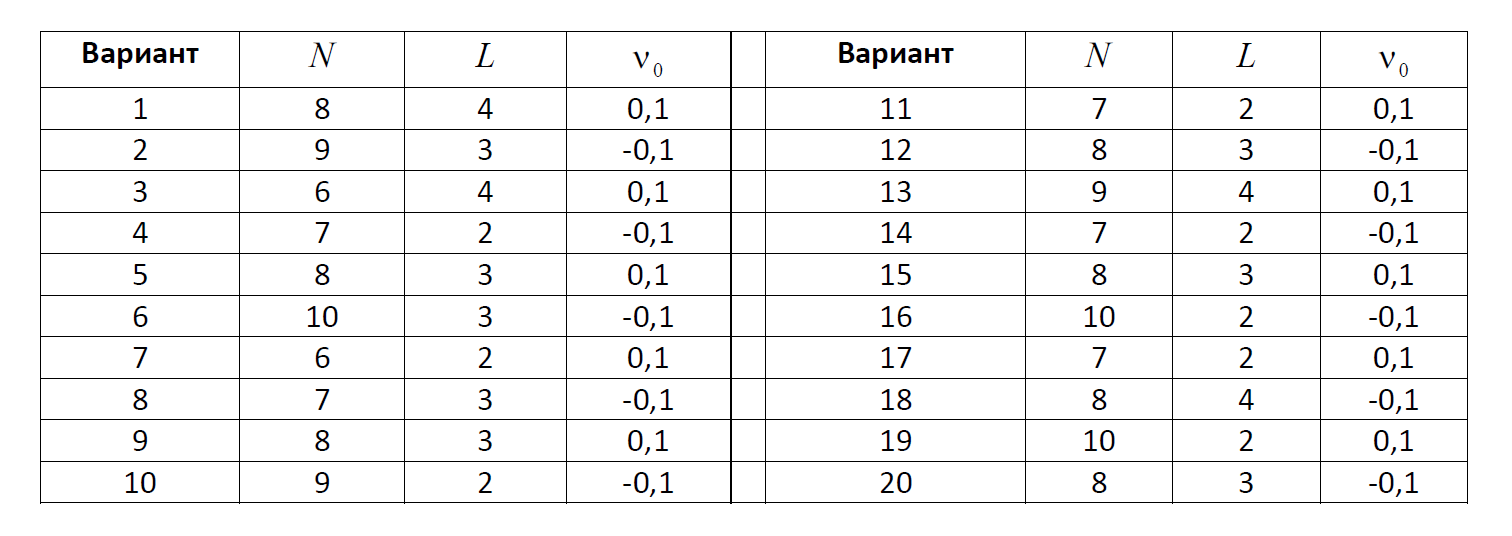

## Задача 1.1.  Прямоугольный импульс в дискретной форме.  

С помощью моделирования  вычислите и постройте график для модуля и фазы ДВПФ  $X_N(\nu)$  последовательности из $N$ последовательных единичных импульсов ${{x}_{N}}[k]=\sum\limits_{m=0}^{N-1}{\mathbf{1}}\left[ k-m \right]$ для $\nu \in [-0,5; \;0,5]$.  Сравните результат с аналитической записью для  $X_N(\nu)$ (задача 1.б из задания к допуску).  Заполнить таблицу, используя результаты моделирования и аналитические записи. Принять частоту дискретизации равной 1 Гц. 

| Значение <br> X(0)  | Ширина $\Delta\nu$ главного лепестка <br> на нулевом уровне |  Точки скачков фазы <br> на $\pi$  |  Энергия$^2$ $\times\Delta t$ <br> $${\int_{-1/2}^{1/2}{|}X(\nu ){{|}^{2}}d\nu} $$  |
|:-----------:|:---:|:---:|:---:|
|             |     |     |     |

$^2$ Для дискретного сигнала рассматривают энергию $\int_{-1/2}^{1/2}{|}X(\nu ){{|}^{2}}d\nu $, приходящуюся на один период частоты, т.е. на полосу частот шириной ${{f}_{\text{д}}}$:

$\int_{-0,5{{f}_{\text{д}}}}^{0,5{{f}_{\text{д}}}}{|}X(f){{|}^{2}}df=\frac{1}{\Delta t}\int_{-1/2}^{1/2}{|}X(\nu ){{|}^{2}}d\nu $
Для ее вычисления можно воспользоваться равенством Парсеваля для ДВПФ. 


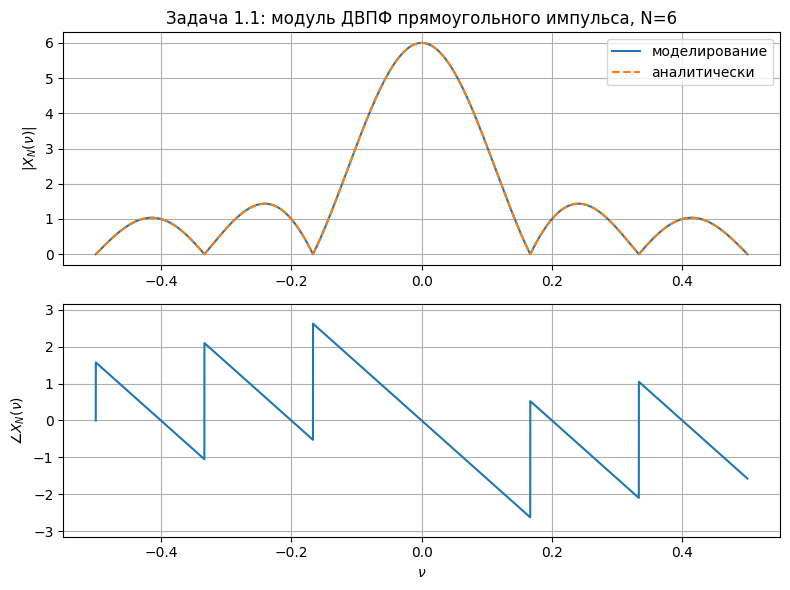

Аналитическая запись: X_N(nu)=exp(-j*pi*nu*(N-1))*sin(pi*N*nu)/sin(pi*nu), в nu=0 предел равен N.
X(0) = 6
Ширина главного лепестка по нулям Delta nu = 2/N = 0.333333
Точки скачков фазы на pi: -0.5, -0.333333, -0.166667, 0.166667, 0.333333, 0.5
Энергия по Парсевалю int |X(nu)|^2 dnu = sum |x[k]|^2 = 6


In [3]:

# Вариант 7
N = 6
L = 2
nu_0 = 0.1
m0 = 7
m1 = 0.6

plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True

def dtft(x, M=8192):
    nu = np.arange(M) / M - 0.5
    X = np.fft.fftshift(np.fft.fft(x, M))
    return nu, X

def rect_dtft(nu, N):
    nu = np.asarray(nu)
    den = np.sin(np.pi * nu)
    num = np.sin(np.pi * N * nu)
    ratio = np.empty_like(nu, dtype=float)
    mask = np.isclose(den, 0.0, atol=1e-12)
    ratio[~mask] = num[~mask] / den[~mask]
    ratio[mask] = N * np.cos(np.pi * (N - 1) * nu[mask]) / np.cos(np.pi * (N - 1) * nu[mask])
    return np.exp(-1j * np.pi * (N - 1) * nu) * ratio

xN = np.ones(N)
nu, X_num = dtft(xN)
X_an = rect_dtft(nu, N)

plt.figure(figsize=(8, 6))
plt.subplot(2, 1, 1)
plt.plot(nu, np.abs(X_num), label='моделирование')
plt.plot(nu, np.abs(X_an), '--', label='аналитически')
plt.title(f'Задача 1.1: модуль ДВПФ прямоугольного импульса, N={N}')
plt.ylabel('$|X_N(\\nu)|$')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(nu, np.angle(X_num), label='моделирование')
plt.ylim([-np.pi, np.pi])
plt.xlabel('$\\nu$')
plt.ylabel('$\\angle X_N(\\nu)$')
plt.tight_layout()
plt.show()

phase_jumps = [r / N for r in range(-N//2, N//2 + 1) if r != 0 and -0.5 <= r / N <= 0.5]
energy = np.sum(np.abs(xN) ** 2)
print('Аналитическая запись: X_N(nu)=exp(-j*pi*nu*(N-1))*sin(pi*N*nu)/sin(pi*nu), в nu=0 предел равен N.')
print(f'X(0) = {N}')
print(f'Ширина главного лепестка по нулям Delta nu = 2/N = {2/N:.6g}')
print('Точки скачков фазы на pi:', ', '.join(f'{v:.6g}' for v in phase_jumps))
print(f'Энергия по Парсевалю int |X(nu)|^2 dnu = sum |x[k]|^2 = {energy:g}')


## Задача 1.2.  Свойство масштабирования. 

Постройте последовательность ${{x}_{L}}[k]=\sum\limits_{m=-\infty }^{\infty }{{{x}_{N}}}[m]\mathbf{1}[k-mL]$, добавив $L-1$ нулевой отсчет между каждой парой соседних отсчетов сигнала ${{x}_{N}}[k]$ (из задачи 1.1). С помощью моделирования постройте модуль ее ДВПФ для $\nu \in [-0,5; \;0,5]$ и сравните результат с ${{X}_{N}}(\nu L)$ (из задачи 1.1).


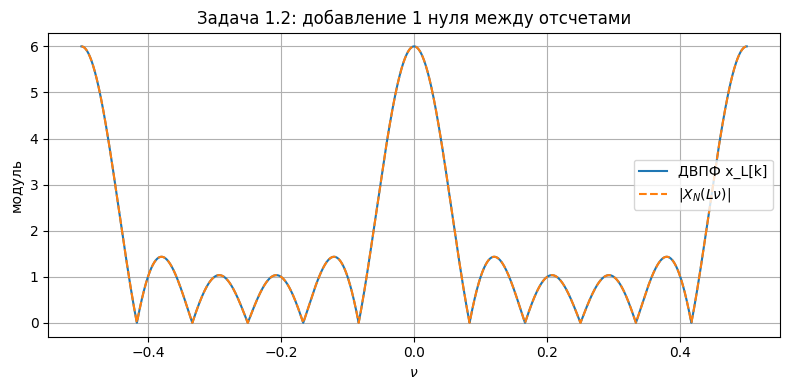

При добавлении L-1 нулей между отсчетами спектр сжимается/периодически повторяется: X_L(nu)=X_N(L*nu).


In [4]:

xL = np.zeros((N - 1) * L + 1)
xL[::L] = xN
nu, XL = dtft(xL)
XL_theory = rect_dtft((nu * L + 0.5) % 1 - 0.5, N)

plt.figure()
plt.plot(nu, np.abs(XL), label='ДВПФ x_L[k]')
plt.plot(nu, np.abs(XL_theory), '--', label='$|X_N(L\\nu)|$')
plt.title(f'Задача 1.2: добавление {L-1} нуля между отсчетами')
plt.xlabel('$\\nu$')
plt.ylabel('модуль')
plt.legend()
plt.tight_layout()
plt.show()

print('При добавлении L-1 нулей между отсчетами спектр сжимается/периодически повторяется: X_L(nu)=X_N(L*nu).')


## Задача 1.3.  Дифференцирование спектральной плотности.
Рассмотрите последовательность ${{x}_{D}}[k]=k\,{{x}_{N}}[k]$.  Постройте с помощью моделирования график для модуля ДВПФ этой последовательности ${{X}_{D}}(\nu )$ для $\nu \in [-0,5; \;0,5]$. 

** Получить численным или символьным дифференцированием график для $\frac{j}{2\pi }\frac{d{{X}_{N}}(\nu )}{d\nu }$ и сравнить его с ${{X}_{D}}(\nu ).$ 


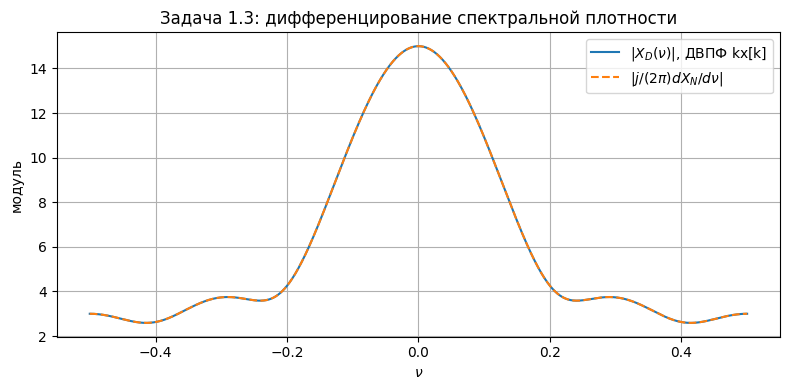

Максимальное расхождение на расчетной сетке: 5.752e-03.
Свойство подтверждается: умножение на k во времени соответствует (j/2pi) dX/dnu в частотной области.


In [5]:

k = np.arange(N)
xD = k * xN
nu, XD = dtft(xD)
XN = rect_dtft(nu, N)
dXN_dnu = np.gradient(XN, nu)
XD_from_derivative = 1j / (2 * np.pi) * dXN_dnu

plt.figure()
plt.plot(nu, np.abs(XD), label='$|X_D(\\nu)|$, ДВПФ kx[k]')
plt.plot(nu, np.abs(XD_from_derivative), '--', label='$|j/(2\\pi) dX_N/d\\nu|$')
plt.title('Задача 1.3: дифференцирование спектральной плотности')
plt.xlabel('$\\nu$')
plt.ylabel('модуль')
plt.legend()
plt.tight_layout()
plt.show()

err = np.max(np.abs(XD - XD_from_derivative))
print(f'Максимальное расхождение на расчетной сетке: {err:.3e}.')
print('Свойство подтверждается: умножение на k во времени соответствует (j/2pi) dX/dnu в частотной области.')


## Задача 1.4. Теорема смещения.
С помощью моделирования получите график модуля спектральной плотности ${{X}_{S}}(\nu )$ для сигнала ${{x}_{S}}[k]={{x}_{N}}[k]\exp (j2\pi {{\nu }_{0}}k)$. Приведите ответы на следующие вопросы.

а) Какую аналитическую форму записи имеет функция ${{X}_{S}}(\nu )$?

б) Как результат моделирования соотносится с теоремой смещения для ДВПФ? 

в) Почему получившийся спектр не симметричен относительно нулевой частоты? 


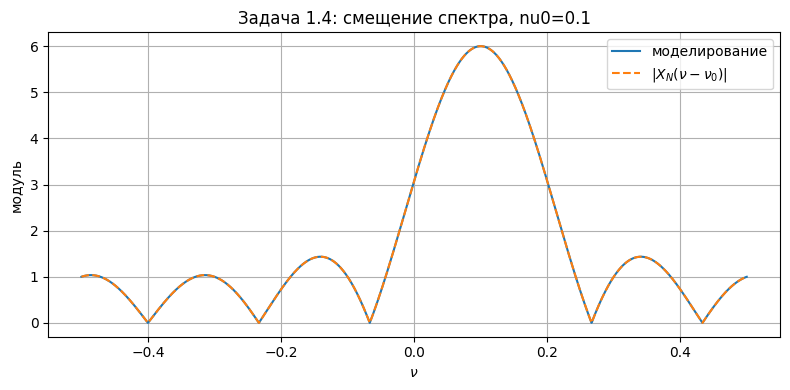

а) X_S(nu)=X_N(nu-nu0).
б) Моделирование совпадает с теоремой смещения ДВПФ: максимум спектра переносится к nu0.
в) Сигнал x_S[k] комплексный, поэтому эрмитова симметрия спектра действительного сигнала не выполняется.


In [6]:

k = np.arange(N)
xS = xN * np.exp(1j * 2 * np.pi * nu_0 * k)
nu, XS = dtft(xS)
XS_theory = rect_dtft((nu - nu_0 + 0.5) % 1 - 0.5, N)

plt.figure()
plt.plot(nu, np.abs(XS), label='моделирование')
plt.plot(nu, np.abs(XS_theory), '--', label='$|X_N(\\nu-\\nu_0)|$')
plt.title(f'Задача 1.4: смещение спектра, nu0={nu_0}')
plt.xlabel('$\\nu$')
plt.ylabel('модуль')
plt.legend()
plt.tight_layout()
plt.show()

print('а) X_S(nu)=X_N(nu-nu0).')
print('б) Моделирование совпадает с теоремой смещения ДВПФ: максимум спектра переносится к nu0.')
print('в) Сигнал x_S[k] комплексный, поэтому эрмитова симметрия спектра действительного сигнала не выполняется.')


## Задача 1.5. Теорема о свертке во временной области. 

Вычислите с помощью моделирования линейную дискретную свертку последовательности ${{x}_{N}}[k]=\sum\limits_{m=0}^{N-1}{\mathbf{1}}\left[ k-m \right]$ с точно такой же последовательностью. Постройте график для модуля ДВПФ  этой последовательности. Воспользовавшись теоремой о свертке, получите аналитическую запись ДВПФ. Заполните таблицу.

| Значение <br> X(0)  | Ширина $\Delta\nu$ главного лепестка <br> на нулевом уровне |  Энергия $\times\Delta t$ <br> $${\int_{-1/2}^{1/2}{|}X(\nu ){{|}^{2}}d\nu} $$  |
|:-----------:|:---:|:--------:|
|             |     |     |

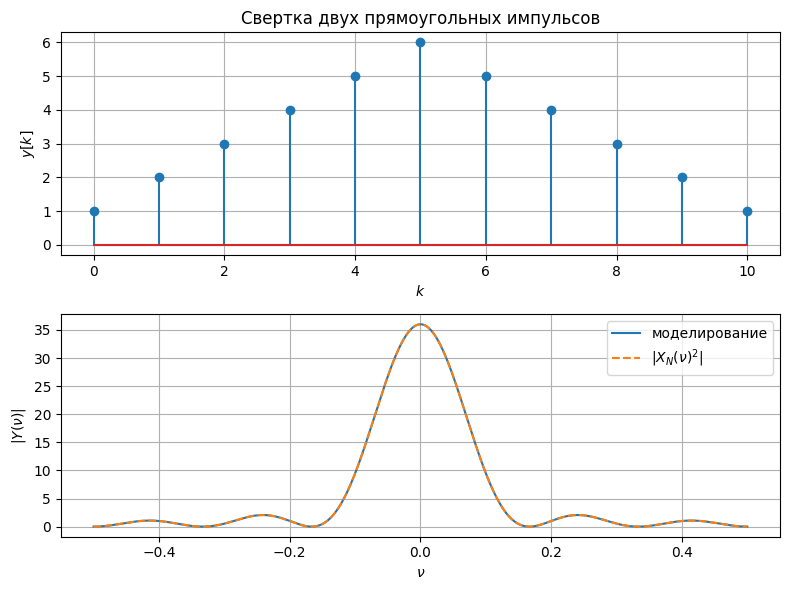

Аналитическая запись: Y(nu)=X_N(nu)^2.
Y(0) = N^2 = 36
Ширина главного лепестка по нулям Delta nu = 2/N = 0.333333
Энергия int |Y(nu)|^2 dnu = sum |y[k]|^2 = 146


In [7]:

y = signal.convolve(xN, xN)
nu, Y = dtft(y)
Y_theory = rect_dtft(nu, N) ** 2

plt.figure(figsize=(8, 6))
plt.subplot(2, 1, 1)
plt.stem(np.arange(len(y)), y)
plt.title('Свертка двух прямоугольных импульсов')
plt.xlabel('$k$')
plt.ylabel('$y[k]$')

plt.subplot(2, 1, 2)
plt.plot(nu, np.abs(Y), label='моделирование')
plt.plot(nu, np.abs(Y_theory), '--', label='$|X_N(\\nu)^2|$')
plt.xlabel('$\\nu$')
plt.ylabel('$|Y(\\nu)|$')
plt.legend()
plt.tight_layout()
plt.show()

print('Аналитическая запись: Y(nu)=X_N(nu)^2.')
print(f'Y(0) = N^2 = {N**2}')
print(f'Ширина главного лепестка по нулям Delta nu = 2/N = {2/N:.6g}')
print(f'Энергия int |Y(nu)|^2 dnu = sum |y[k]|^2 = {np.sum(y**2):g}')


# Занятие 2. Основные свойства ДПФ

Для задач 2.1 и 2.2 последовательность $x[k]$ генерируется с помощью следующего кода. 

In [8]:
Nv = 7 # Nv - номер варианта
np.random.seed(Nv)
x = np.random.rand(Nv+32)-0.5
x


array([-4.23691711e-01,  2.79918792e-01, -6.15907686e-02,  2.23465178e-01,
        4.77989512e-01,  3.84958704e-02,  1.12046366e-03, -4.27948867e-01,
       -2.31561020e-01, -1.17499174e-04,  1.79229996e-01,  3.03739036e-01,
       -1.19058867e-01, -4.34063653e-01, -2.11854401e-01,  4.09593528e-01,
       -2.86614646e-01, -4.78760382e-02,  4.31206020e-01, -4.75100772e-01,
        1.00548917e-01,  4.50129500e-01, -2.69697121e-01,  4.84899192e-02,
        4.09128375e-01, -3.66830554e-01,  2.34125807e-02,  2.50409859e-01,
        1.69013241e-01, -3.22471403e-02, -2.95150910e-01, -9.23411091e-03,
       -1.27615311e-01, -2.25988451e-02, -1.34109614e-01,  3.37917994e-01,
        2.68647507e-01, -1.86005323e-01,  7.26253326e-02])

## Задача 2.1. Алгоритмы вычисления ДПФ. 

Вычислите ДПФ $X[n]$ для последовательности $x[k]$. Воспользуйтесь следующими способами:

а) вычисление с использованием матричной формы ДПФ;

б) алгоритм быстрого преобразование Фурье (БПФ).

Сравните результаты. 


In [9]:

Nd = len(x)
n = np.arange(Nd)
W = dft(Nd)
X_matrix = W @ x
X_fft = np.fft.fft(x)

print(f'Длина последовательности Nv+32 = {Nd}')
print(f'Максимальное отличие матричного ДПФ и БПФ: {np.max(np.abs(X_matrix - X_fft)):.3e}')


Длина последовательности Nv+32 = 39
Максимальное отличие матричного ДПФ и БПФ: 2.921e-14


## Задача 2.2  Свойства симметрии ДПФ. 

Для последовательности $x[k]$ постройте графики $\text{Re}\ X[n]$, $\text{Im}\ X[n]$, $\left| X[n] \right|$, $\angle \ X[n]$.

Сравните получившиеся результаты со свойствами симметрии ДПФ. 


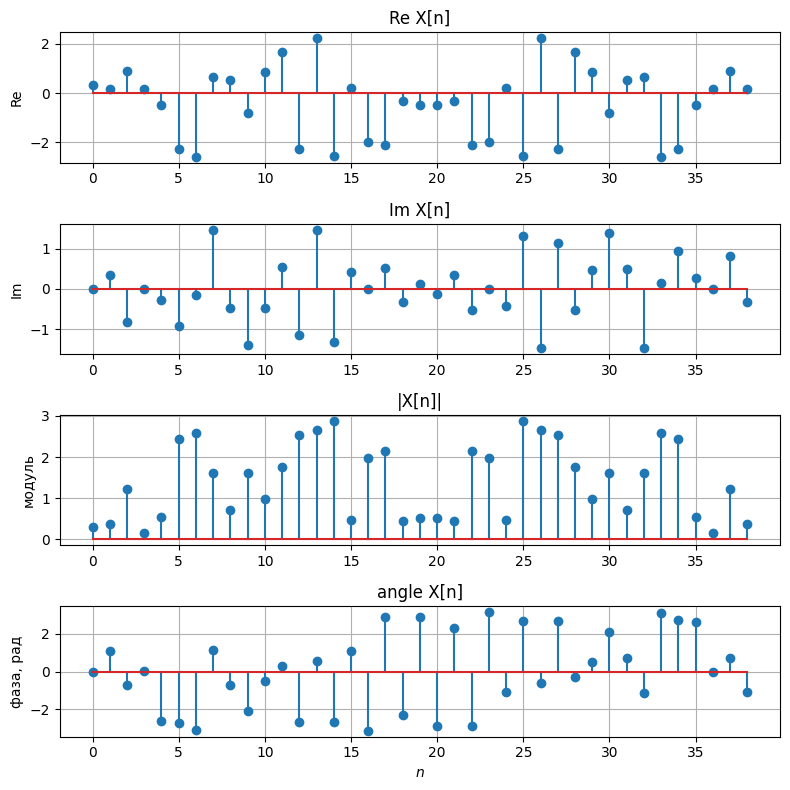

Проверка эрмитовой симметрии X[n]=conj(X[-n mod N]): ошибка 8.882e-16.
Для действительной x[k]: Re X[n] и |X[n]| четные, Im X[n] и фаза нечетные с учетом периодичности ДПФ.


In [10]:

X = np.fft.fft(x)
n = np.arange(len(X))

plt.figure(figsize=(8, 8))
for i, (values, title, ylabel) in enumerate([
    (X.real, 'Re X[n]', 'Re'),
    (X.imag, 'Im X[n]', 'Im'),
    (np.abs(X), '|X[n]|', 'модуль'),
    (np.angle(X), 'angle X[n]', 'фаза, рад'),
], 1):
    plt.subplot(4, 1, i)
    plt.stem(n, values)
    plt.title(title)
    plt.ylabel(ylabel)
plt.xlabel('$n$')
plt.tight_layout()
plt.show()

sym_err = np.max(np.abs(X - np.conj(np.roll(X[::-1], 1))))
print(f'Проверка эрмитовой симметрии X[n]=conj(X[-n mod N]): ошибка {sym_err:.3e}.')
print('Для действительной x[k]: Re X[n] и |X[n]| четные, Im X[n] и фаза нечетные с учетом периодичности ДПФ.')


## Задача 2.3.  Циклический сдвиг в ДПФ. 


Постройте график для последовательности $q[k]=k+1$ при $0\le k < 8$, иначе  $q[k]=0$.

Вычислите последовательность $y[k]$, ДПФ которой 
$Y[n]=\exp \left( -j\frac{2\pi }{8}mn \right)Q[n]$.

Сравните получившиеся последовательности. 


Параметр $m$ для задачи 2.3 генерируется с помощью следующего кода. 

In [11]:
Nv = 7 # Nv - номер варианта
m = max(Nv % 8, 1)
print('m =', m)


m = 7


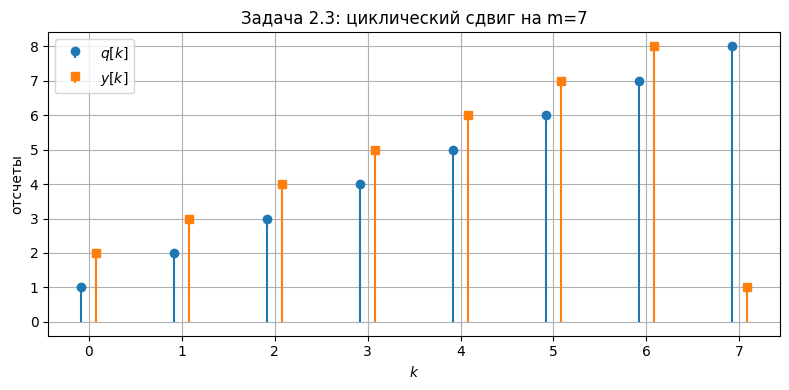

q[k] = [1 2 3 4 5 6 7 8]
y[k] = [2 3 4 5 6 7 8 1]
Ожидаемый циклический сдвиг вправо на m: [2 3 4 5 6 7 8 1]
Максимальная ошибка: 6.335e-15


In [12]:

Nq = 8
k = np.arange(Nq)
q = k + 1
Q = np.fft.fft(q)
n = np.arange(Nq)
Y = np.exp(-1j * 2 * np.pi * m * n / Nq) * Q
y = np.fft.ifft(Y)
y_expected = np.roll(q, m)

plt.figure(figsize=(8, 4))
plt.stem(k - 0.08, q, linefmt='C0-', markerfmt='C0o', basefmt=' ', label='$q[k]$')
plt.stem(k + 0.08, y.real, linefmt='C1-', markerfmt='C1s', basefmt=' ', label='$y[k]$')
plt.xticks(k)
plt.title(f'Задача 2.3: циклический сдвиг на m={m}')
plt.xlabel('$k$')
plt.ylabel('отсчеты')
plt.legend()
plt.tight_layout()
plt.show()

print('q[k] =', q.astype(int))
print('y[k] =', np.rint(y.real).astype(int))
print('Ожидаемый циклический сдвиг вправо на m:', y_expected.astype(int))
print(f'Максимальная ошибка: {np.max(np.abs(y - y_expected)):.3e}')


# Занятие 3. Связь ДВПФ и ДПФ

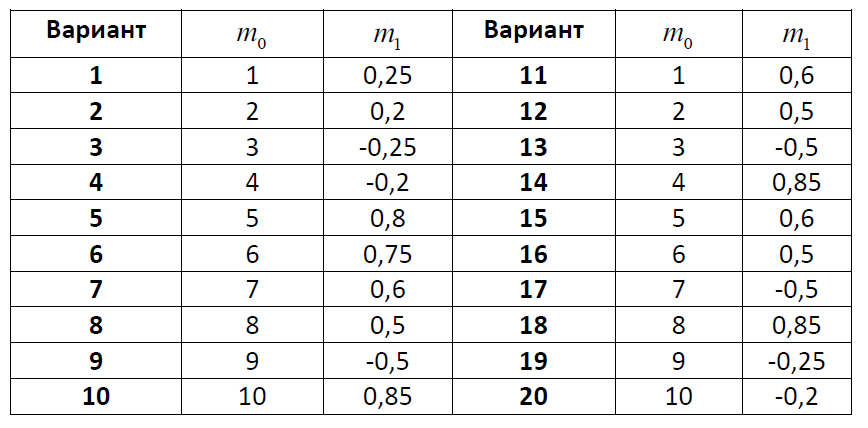

## Задача 3.1. Интерполяция  ДВПФ добавлением нулевых отсчетов в сигнал.

Постройте на одном графике модули ДВПФ $\left| X(\nu ) \right|$ и ДПФ $\left| X[n] \right|$ последовательности ($N=32$)
$$x[k]=\left\{ \begin{array}{*{35}{l}}
   \sin \left( \dfrac{2\pi }{N}{{m}_{0}}k \right)+\sin \left( \dfrac{2\pi }{N}\left( {{m}_{0}}+0,25 \right)k \right),\ 0\le k\le N-1;  \\
   0,\ \ \text{при других }k.  \\
\end{array} \right.$$
Увеличьте размерность ДПФ, добавив нулевые отсчеты так, чтобы все относительные частоты синусоид попадали на бины ДПФ.  Приведите на одном графике модули ДВПФ $\left| X(\nu ) \right|$ и ДПФ $\left| X[n] \right|$  для этого случая. Сравните результаты. 

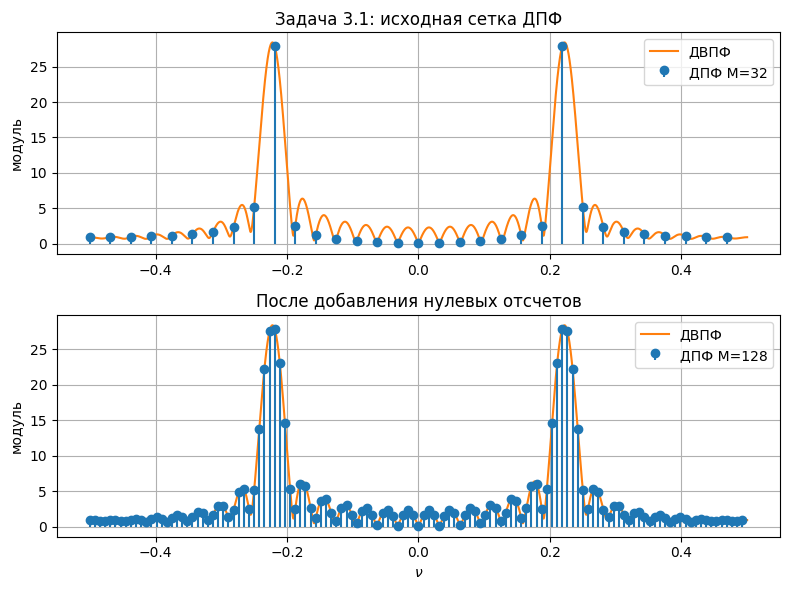

Для m0=7: частоты sin равны 7/32 и 7.25/32.
При M=32 первая частота попадает на бин, вторая нет; видна спектральная утечка.
При M=128 обе частоты соответствуют бинам 28 и 29, поэтому ДПФ точнее интерполирует ДВПФ.


In [13]:

N3 = 32
k = np.arange(N3)
x3 = np.sin(2 * np.pi * m0 * k / N3) + np.sin(2 * np.pi * (m0 + 0.25) * k / N3)

nu, X3 = dtft(x3, M=8192)
M1 = N3
M2 = 128  # 7/32=28/128 и 7.25/32=29/128 попадают на бины ДПФ

plt.figure(figsize=(8, 6))
plt.subplot(2, 1, 1)
plt.plot(nu, np.abs(X3), 'C1', label='ДВПФ')
plt.stem(np.arange(M1)/M1 - 0.5, np.abs(np.fft.fftshift(np.fft.fft(x3, M1))), linefmt='C0-', markerfmt='C0o', basefmt=' ', label=f'ДПФ M={M1}')
plt.title('Задача 3.1: исходная сетка ДПФ')
plt.ylabel('модуль')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(nu, np.abs(X3), 'C1', label='ДВПФ')
plt.stem(np.arange(M2)/M2 - 0.5, np.abs(np.fft.fftshift(np.fft.fft(x3, M2))), linefmt='C0-', markerfmt='C0o', basefmt=' ', label=f'ДПФ M={M2}')
plt.title('После добавления нулевых отсчетов')
plt.xlabel('$\\nu$')
plt.ylabel('модуль')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Для m0={m0}: частоты sin равны {m0}/{N3} и {m0+0.25}/{N3}.')
print('При M=32 первая частота попадает на бин, вторая нет; видна спектральная утечка.')
print(f'При M={M2} обе частоты соответствуют бинам 28 и 29, поэтому ДПФ точнее интерполирует ДВПФ.')


## Задача 3.2. ДВПФ и ДПФ периодической последовательсти.

Простройте графики для действительной  и мнимой части коэффициентов ДПФ $\tilde{X}[n]$ периодической последовательности $x[k]=\cos \left( \frac{2\pi }{N}mk \right)+\sin \left( \frac{2\pi }{N}mk \right)$  с периодом $N=32$, для случаев $m={{m}_{0}}$ и $m={{m}_{0}}+{{m}_{1}}$. Получите аналитическую запись ДПФ. Сравните ДПФ последовательности с ее ДВПФ. Определите, выполняется ли связь между весами дельта-функций в ДВПФ и величинами отсчетов ДПФ. 

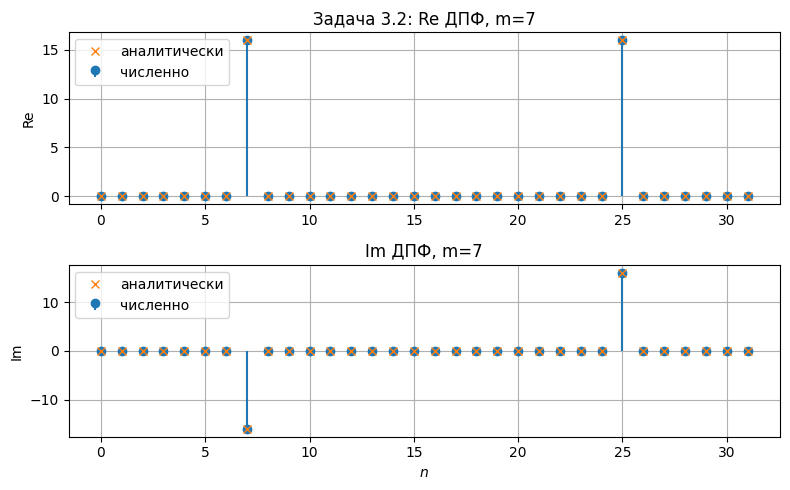

m=7: максимальное отличие численной и аналитической формулы ДПФ = 4.453e-14


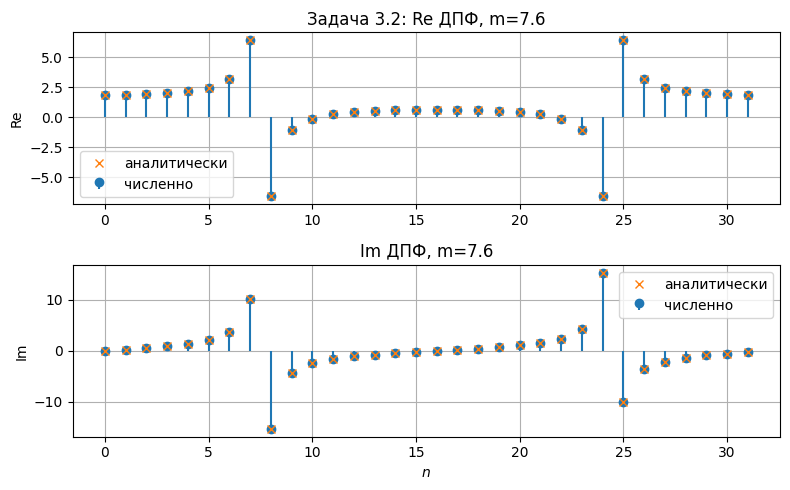

m=7.6: максимальное отличие численной и аналитической формулы ДПФ = 1.070e-13
Для целого m=m0=7: X[7]=16(1-j), X[25]=16(1+j), остальные отсчеты равны нулю с точностью округления.
Это соответствует ДВПФ периодической последовательности: веса дельта-функций равны нормированным коэффициентам X[n]/N.
Для m=m0+m1=7.6 последовательность не имеет периода 32, поэтому энергия не сосредоточена в двух бинах; наблюдается утечка, а связь с весами дельта-функций 32-периодической последовательности неприменима.


In [14]:

N3 = 32
k = np.arange(N3)

def geom_sum(alpha, N):
    alpha = np.asarray(alpha, dtype=float)
    out = np.empty_like(alpha, dtype=complex)
    mask = np.isclose(np.sin(np.pi * alpha / N), 0, atol=1e-12)
    out[mask] = N
    out[~mask] = np.exp(1j * np.pi * alpha[~mask] * (N - 1) / N) * np.sin(np.pi * alpha[~mask]) / np.sin(np.pi * alpha[~mask] / N)
    return out

def analytical_dft_cos_sin(m, N):
    n = np.arange(N)
    a = (1 - 1j) / 2
    b = (1 + 1j) / 2
    return a * geom_sum(m - n, N) + b * geom_sum(-(m + n), N)

for idx, m_val in enumerate([m0, m0 + m1], 1):
    x_per = np.cos(2 * np.pi * m_val * k / N3) + np.sin(2 * np.pi * m_val * k / N3)
    X_num = np.fft.fft(x_per)
    X_an = analytical_dft_cos_sin(m_val, N3)
    n = np.arange(N3)

    plt.figure(figsize=(8, 5))
    plt.subplot(2, 1, 1)
    plt.stem(n, X_num.real, linefmt='C0-', markerfmt='C0o', basefmt=' ', label='численно')
    plt.plot(n, X_an.real, 'C1x', label='аналитически')
    plt.title(f'Задача 3.2: Re ДПФ, m={m_val}')
    plt.ylabel('Re')
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.stem(n, X_num.imag, linefmt='C0-', markerfmt='C0o', basefmt=' ', label='численно')
    plt.plot(n, X_an.imag, 'C1x', label='аналитически')
    plt.title(f'Im ДПФ, m={m_val}')
    plt.xlabel('$n$')
    plt.ylabel('Im')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f'm={m_val}: максимальное отличие численной и аналитической формулы ДПФ = {np.max(np.abs(X_num-X_an)):.3e}')

print('Для целого m=m0=7: X[7]=16(1-j), X[25]=16(1+j), остальные отсчеты равны нулю с точностью округления.')
print('Это соответствует ДВПФ периодической последовательности: веса дельта-функций равны нормированным коэффициентам X[n]/N.')
print('Для m=m0+m1=7.6 последовательность не имеет периода 32, поэтому энергия не сосредоточена в двух бинах; наблюдается утечка, а связь с весами дельта-функций 32-периодической последовательности неприменима.')


# Примеры вычислений на Python для лабораторной работы №2 "ДВПФ и ДПФ"

## Задание последовательности отсчетов

Зададим последовательность из 10 единичных импульсов $w[k] = \sum_{m=0}^{N-1} \mathbf{1}[k-m]$

In [15]:
w = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
w

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

Сделаем тоже самое с помощью функции `ones`

In [16]:
w1=np.ones(10)
w1

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

Выведем график последовательности $w[k] = \sum_{m=0}^{N-1} \mathbf{1}[k-m]$

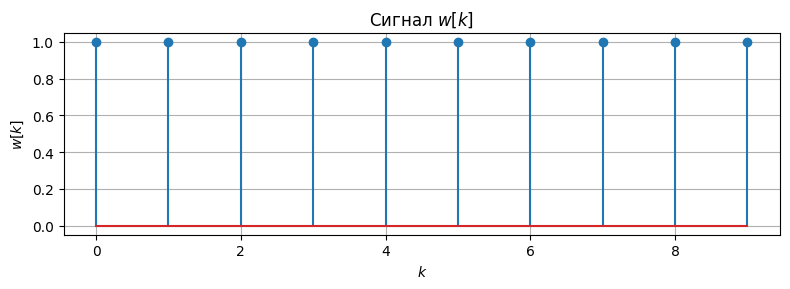

In [17]:
N=len(w)
k = np.arange(N)
plt.figure(figsize=[8, 3])
plt.stem(k, w)
plt.title('Сигнал $w[k]$')
plt.xlabel('$k$')
plt.ylabel('$w[k]$')
plt.tight_layout()
plt.show()

Определим последовательность вида $y[k]=\exp(j2\pi \nu_0 k) w[k]$

In [18]:
k = np.arange(N)
nu_0 = 0.25
y=np.exp(1j*2*np.pi*nu_0*k)
y

array([ 1.0000000e+00+0.0000000e+00j,  6.1232340e-17+1.0000000e+00j,
       -1.0000000e+00+1.2246468e-16j, -1.8369702e-16-1.0000000e+00j,
        1.0000000e+00-2.4492936e-16j,  3.0616170e-16+1.0000000e+00j,
       -1.0000000e+00+3.6739404e-16j, -4.2862638e-16-1.0000000e+00j,
        1.0000000e+00-4.8985872e-16j,  5.5109106e-16+1.0000000e+00j])

Определим дискретную линейную свертку (Convolution) последовательности $w[k]$ c точно такой же последовательностью.

In [19]:
w2=signal.convolve(w, w)
w2

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10,  9,  8,  7,  6,  5,  4,  3,
        2,  1])

Выведем график для такой последовательности:

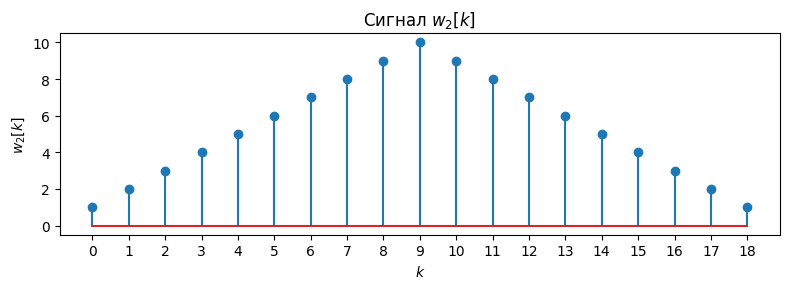

In [20]:
N=len(w2)
k = np.arange(0, N)
plt.figure(figsize=[8, 3])
plt.stem(k, w2)
plt.title('Сигнал $w_2[k]$')
plt.xlabel('$k$')
plt.ylabel('$w_2[k]$')
plt.grid()
plt.xticks(k) # установить деления шкалы абсцисс для каждого отсчета
plt.tight_layout()
plt.show()

Поэлементное умножение задается оператором `*`

In [21]:
w2*w2

array([  1,   4,   9,  16,  25,  36,  49,  64,  81, 100,  81,  64,  49,
        36,  25,  16,   9,   4,   1])

## Вычисление ДВПФ

Определим ДВПФ последовательности $w[k]=\sum_{m=0}^{N-1} \mathbf{1}[k-m]$ 

In [22]:
def dtft(x, M=2048):
    return  np.arange(M)/M-0.5, np.fft.fftshift(np.fft.fft(x, M))

In [23]:
nu, W = dtft(w, M=2048)

* `nu` — массив частот $\nu \in [-0.5;0.5)$ с шагом сетки $\Delta \nu =1/M$,
* `W` — значения ДВПФ $W(\nu )$ в этих точках, 
* `dtft` — функция, 
* `w` — последовательность отсчетов, 
* `M` — число точек на сетки оси частот, в которых вычисляется ДВПФ. 

Построим график для модуля ДВПФ

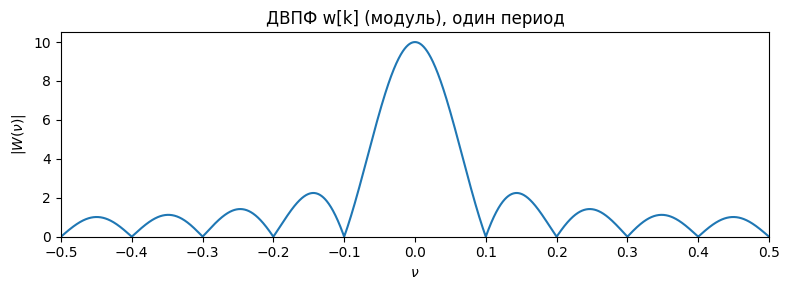

In [24]:
plt.figure(figsize=[8, 3])
nu, W = dtft(w, M=2048)
plt.plot(nu, abs(W))

plt.xlim([-0.5, 0.5])
plt.ylim(bottom=0)
plt.title('ДВПФ w[k] (модуль), один период')
plt.xlabel('$\\nu$')
plt.ylabel('$|W(\\nu)|$')

plt.xticks(np.linspace(-0.5, 0.5, 11))
plt.grid()
plt.tight_layout()
plt.show()

Теперь выведем фазовую часть ДВПФ

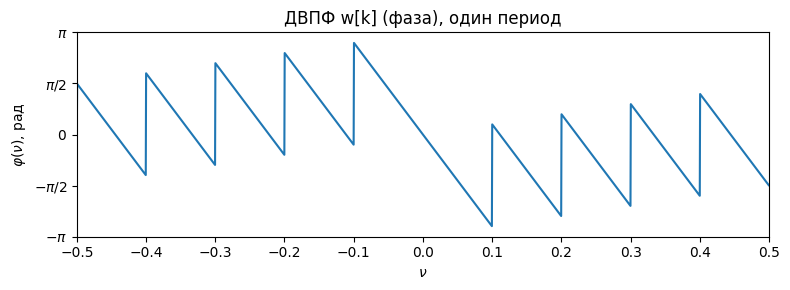

In [25]:
plt.figure(figsize=[8, 3])
plt.plot(nu, np.angle(W))
plt.xlim([-0.5, 0.5])
plt.ylim([-np.pi, np.pi])
plt.title('ДВПФ w[k] (фаза), один период')
plt.xlabel('$\\nu$')
plt.ylabel('$\\varphi(\\nu)$, рад')
plt.yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=("$-\\pi$", "$-\\pi/2$", "$0$", "$\\pi/2$", "$\\pi$"))
plt.xticks(np.linspace(-0.5, 0.5, 11))
plt.grid()
plt.tight_layout()
plt.show()

## Вычисление ДПФ

Вычислим ДПФ $N$-точечной последовательности

$$x[k]=\sin \left(2\pi \frac{2}{N}k\right)+\cos \left(2\pi \frac{3}{N}k\right),\;\;k=0,1,\dots ,N-1,\;\;N=8.$$

Формула прямого ДПФ в данном случае без нормирующего множителя $1/N$:
$$X[n]=\sum_{k=0}^{N-1} x[k]\exp \left(-j2\pi \frac{nk}{N}\right)$$
Сначала воспользуемся матричной формой ДПФ. Функция `scipy.linalg.dft(N)` возвращает матрицу ДПФ $[W]_N$ размера $N\times N$. 


In [26]:
N=8
k=np.arange(N)
x=np.sin(2*np.pi*2/N*k)+np.cos(2*np.pi*3/N*k)
W8 = dft(N)
Xn = W8 @ x
Xn

array([-8.07156228e-17+0.00000000e+00j,  8.88178420e-16-7.67444448e-16j,
        1.85570158e-16-4.00000000e+00j,  4.00000000e+00+8.90860265e-17j,
        1.25155201e-15+9.86076132e-31j,  4.00000000e+00+4.71970162e-15j,
       -5.11882929e-15+4.00000000e+00j,  2.22044605e-16-2.51954864e-15j])

Построим графики. 

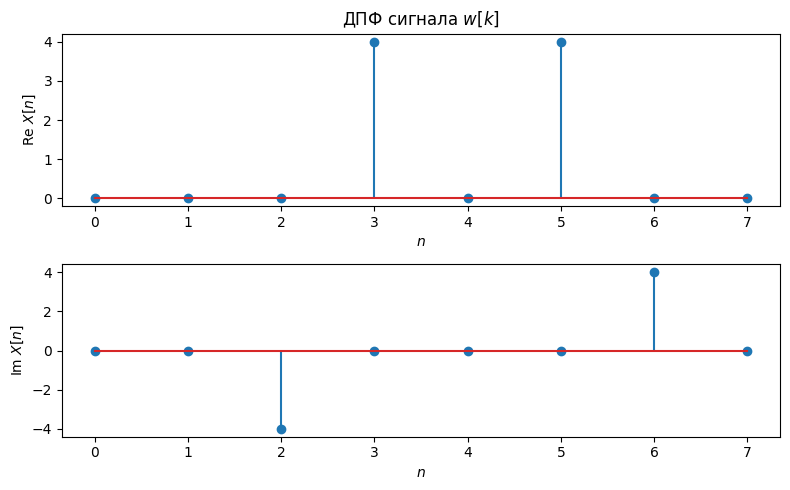

In [27]:
plt.figure(figsize=[8, 5])

n=np.arange(N)
plt.subplot(2, 1, 1)
plt.stem(n, Xn.real)
plt.xticks(n)
plt.title('ДПФ сигнала $w[k]$')
plt.xlabel('$n$')
plt.ylabel('Re $X[n]$')
plt.grid()

plt.subplot(2, 1, 2)
plt.stem(n, Xn.imag)
plt.xticks(n)
plt.xlabel('$n$')
plt.ylabel('Im $X[n]$')

plt.grid()
plt.tight_layout()
plt.show()

Теперь проведем вычисление ДПФ по алгоритму быстрого преобразования Фурье (БПФ). Для этого воспользуемся функцией `np.fft.fft()`.


In [28]:
Xn1=np.fft.fft(x)
Xn1

array([-3.09256603e-17+0.00000000e+00j,  6.66133815e-16+1.94671210e-16j,
       -1.07929736e-15-4.00000000e+00j,  4.00000000e+00-1.76476367e-15j,
        1.30134197e-15+0.00000000e+00j,  4.00000000e+00+1.76476367e-15j,
       -1.07929736e-15+4.00000000e+00j,  6.66133815e-16-1.94671210e-16j])

Сравним результаты.

In [29]:
max(abs(Xn1-Xn))

np.float64(4.2535579475330355e-15)

## Вычисление обратного ДПФ


Матрица обратного ДПФ может быть найдена как обратная матрица для $[W]_N$.

In [30]:
W8_inv1 = np.linalg.inv(W8)

Также ее можно получить с помощью транспонирования и комплексного сопряжения (эрмитова сопряжения) c дополнительной нормировкой на $N$, в силу того, что $[W]_N^{-1} =\frac{1}{N}{\left([W]_N^T \right)}^* =\frac{1}{N}[W]_N^*$. 


In [31]:
W8_inv2 = np.conjugate(W8) / N

Вычислим обратное ДПФ, используя матричную форму. Сравним результат с исходной последовательностью. 


In [32]:
x1 = W8_inv1 @ Xn
max(abs(x1-x))

np.float64(6.509263200420946e-16)

Выполним те же вычисления с использованием алгоритма БПФ. Для этого нам понадобится функция `np.fft.ifft()`

In [33]:
x2=np.fft.ifft(Xn)
max(abs(x2-x))

np.float64(1.526600783182116e-15)

## Интерполяция ДВПФ добавлением нулевых отсчетов

Построим на одном графике модули ДПФ и ДВПФ $N$-точечной последовательности ($N=16$)

$$x[k]=\sin \left(2\pi \frac{5.5}{16} k \right),\;\;k=0,1,\dots ,N-1.$$

In [34]:
N=16
k=np.arange(N)
n=np.arange(N)
x=np.sin(2*np.pi*5.5*k/N)

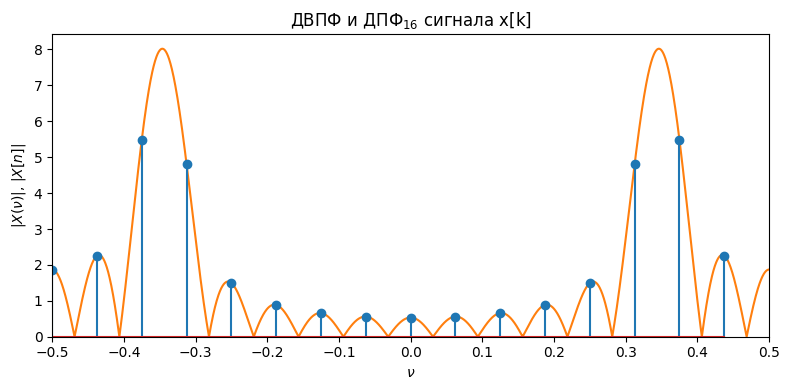

In [35]:
plt.figure(figsize=[8, 4])


nu, X = dtft(x, M=2048)
plt.plot(nu, abs(X), 'C1')

M=N
plt.stem(np.arange(M)/M-0.5, abs(np.fft.fftshift(np.fft.fft(x, M))), linefmt='C0', markerfmt='C0o')

plt.xlim([-0.5, 0.5])
plt.ylim(bottom=0)
plt.title('ДВПФ и ДПФ$_{%i}$ сигнала x[k]' %M)
plt.xlabel('$\\nu$')
plt.ylabel('$|X(\\nu)|$, $|X[n]|$')
plt.xticks(np.linspace(-0.5, 0.5, 11))
plt.grid()
plt.tight_layout()
plt.show()

Здесь функция `np.fft.fftshift` позволяет циклически сдвинуть вычисленные отсчеты ДПФ так, чтобы они соответствовали частотам$\nu_n \in [-0.5;0.5)$, $\nu_n =-0.5+\frac{n}{N}.$

Относительная частота синусойды $\nu_0 =\frac{6.5}{16}$ не попадет на сетку частот ДПФ. В результате спектральные максимумы недостаточно хорошо визуализируются отсчетами ДПФ. Чтобы это улучшить, добавим к последовательности, используемой при вычислении ДПФ, нулевые отсчеты в конец сигнала. Для этого досточно указать второй параметр функции `np.fft.fft(x, M)` равный новому числу отсчетов. 


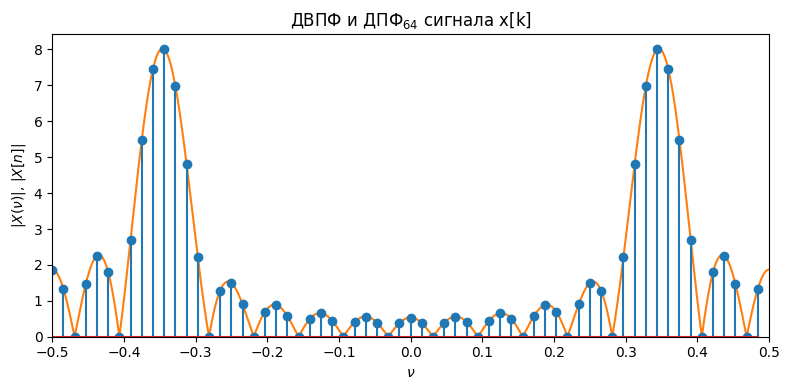

In [36]:
plt.figure(figsize=[8, 4])


nu, X = dtft(x, M=2048)
plt.plot(nu, abs(X), 'C1')

Nz=48
M=N+Nz
plt.stem(np.arange(M)/M-0.5, abs(np.fft.fftshift(np.fft.fft(x, M))), linefmt='C0', markerfmt='C0o')

plt.xlim([-0.5, 0.5])
plt.ylim(bottom=0)
plt.title('ДВПФ и ДПФ$_{%i}$ сигнала x[k]' %M)
plt.xlabel('$\\nu$')
plt.ylabel('$|X(\\nu)|$, $|X[n]|$')
plt.xticks(np.linspace(-0.5, 0.5, 11))
plt.grid()
plt.tight_layout()
plt.show()